In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt, models as md, backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok=True)
print("Imports OK")

Imports OK


In [3]:
airline_returns, macro_returns, prices = dt.load_data()
airline_returns = airline_returns[airline_returns.index >= dt.test_start]
macro_returns = macro_returns[macro_returns.index >= dt.test_start]
print(f"Running validation period only: {airline_returns.index[0].date()} → {airline_returns.index[-1].date()}")
lookback = md.lookback
zscore_window = 20
n_components = md.n_components

covs = md.rolling_covariances(
    airline_returns, window=lookback, use_ledoit_wolf=True
)
_, residuals, _, _, _ = md.compute_factor_model(
    airline_returns, covs, n_components
)
pc1 = md.compute_pc1_concentration(covs)

zscores_raw = md.compute_rolling_zscore(residuals, window=zscore_window).dropna()

zscores = zscores_raw.ewm(span=3, min_periods=2).mean()

print(f"Residuals: {residuals.shape}")
print(f"Z-scores: {zscores.shape}")
print(f"Z-score stats after EMA smoothing:")
print(zscores.describe().round(3))

entry = bt.entry_threshold
n_long_sigs = (zscores < -entry).sum().sum()
n_short_sigs = (zscores > entry).sum().sum()
print(f"\nSignal counts at ±{entry}:")
print(f"Long candidates: {n_long_sigs}")
print(f"Short candidates: {n_short_sigs}")

Airlines: 7 tickers
Macro: 4 tickers
Dates: 2903 trading days
Range: 2015-01-05 -> 2026-07-16
Training: 2015-01-05 -> 2019-12-31
Validation: 2022-01-01 -> 2026-07-16
Running validation period only: 2022-01-03 → 2026-07-16
Residuals: (1051, 7)
Z-scores: (1042, 7)
Z-score stats after EMA smoothing:
            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1041.000  1041.000  1041.000  1041.000  1041.000  1041.000  1041.000
mean      0.008     0.001    -0.003     0.011     0.006    -0.014    -0.008
std       0.583     0.570     0.589     0.575     0.583     0.589     0.581
min      -2.566    -2.004    -2.315    -2.295    -1.986    -2.143    -2.424
25%      -0.339    -0.369    -0.390    -0.320    -0.336    -0.377    -0.351
50%       0.009    -0.028    -0.007     0.028     0.007    -0.013    -0.006
75%       0.356     0.350     0.380     0.389     0.348     0.334     0.337
max       2.332     2.197     2.340     2.217     1.969     2.006     2.303

Signal counts at 

In [4]:
print("Signal Generation Sanity Check")
print(f"Entry threshold: {bt.entry_threshold}")
print(f"Exit threshold: {bt.exit_threshold}")
print(f"Z-score max: {zscores.abs().max().max():.3f}")
print(f"Z-score 95th pct: {zscores.abs().quantile(0.95).mean():.3f}")
pct_above = (zscores.abs() > bt.entry_threshold).mean().mean()
print(f"% days above threshold: {pct_above:.2%}")
if pct_above < 0.01:
    print("WARNING: < 1% of days generate signals — lower threshold or remove EMA")
elif pct_above > 0.20:
    print("WARNING: > 20% of days generate signals — raise threshold")
else:
    print("OK: signal frequency in acceptable range")

Signal Generation Sanity Check
Entry threshold: 1.5
Exit threshold: 0.75
Z-score max: 2.566
Z-score 95th pct: 1.180
% days above threshold: 1.97%
OK: signal frequency in acceptable range


In [5]:
zscores = zscores.ewm(span=3, min_periods=2).mean()
print("Z-scores smoothed with EMA(3)")
print(zscores.describe().round(3))

Z-scores smoothed with EMA(3)
            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1040.000  1040.000  1040.000  1040.000  1040.000  1040.000  1040.000
mean      0.007     0.002    -0.002     0.010     0.006    -0.014    -0.007
std       0.434     0.421     0.442     0.431     0.431     0.439     0.431
min      -1.839    -1.550    -1.417    -1.710    -1.473    -1.583    -1.663
25%      -0.253    -0.285    -0.303    -0.265    -0.248    -0.305    -0.278
50%       0.012    -0.020    -0.011     0.022     0.018    -0.002    -0.001
75%       0.267     0.256     0.306     0.295     0.269     0.256     0.273
max       1.680     1.377     1.749     1.655     1.303     1.551     1.504


In [6]:
signals = bt.generate_signals(zscores,
                              entry = bt.entry_threshold,
                              exit_ = bt.exit_threshold,
                              top_n = bt.top_n,
                              min_hold=bt.min_hold_days,
                              momentum = True,
                             )
active = (signals != 0).any(axis=1)
print(f"Active days: {active.sum()} / {len(signals)} ({active.mean():.1%})")
print(f"\nSignal value counts:")
print(signals.stack().value_counts())
signals.head()

Active days: 61 / 1042 (5.9%)

Signal value counts:
 0.0    7223
-1.0      36
 1.0      35
Name: count, dtype: int64


,DAL,UAL,AAL,LUV,ALK,JBLU,CPA
2022-05-25,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-05-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-05-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-05-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-06-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
holding_periods = []
for col in signals.columns:
    s = signals[col]
    in_pos = False
    count = 0
    for val in s:
        if val != 0:
            count += 1
            in_pos = True
        elif in_pos:
            holding_periods.append(count)
            count = 0
            in_pos = False
    if in_pos and count > 0:
        holding_periods.append(count)

if len(holding_periods) == 0:
    print("No completed positions found.")
    print("Either no signals fired or all positions still open.")
else:
    holding_s = pd.Series(holding_periods)
    print(f"Holding period distribution:")
    print(f"Min: {holding_s.min():.0f} days (should be ≥ 5)")
    print(f"Median: {holding_s.median():.0f} days")
    print(f"Mean: {holding_s.mean():.1f} days")
    print(f"Max: {holding_s.max():.0f} days")
    print(f"Positions shorter than 5 days: {(holding_s < 5).sum()}")

Holding period distribution:
Min: 5 days (should be ≥ 5)
Median: 5 days
Mean: 5.1 days
Max: 6 days
Positions shorter than 5 days: 0


In [8]:
active_days = signals[signals.abs().sum(axis=1) > 0]
positions_per_day = signals.abs().sum(axis=1)
print(f"Position count distribution:")
print(positions_per_day[positions_per_day > 0].value_counts().sort_index())

Position count distribution:
1.0    51
2.0    10
Name: count, dtype: int64


In [9]:
rolling_q95 = zscores.abs().rolling(20).quantile(0.95)
print("Rolling 95th percentile of |z-scores|:")
print(rolling_q95.describe().round(3))
print(f"\nFixed threshold 1.25 corresponds to approx the "
      f"{(zscores.abs() > 1.25).mean().mean()*100:.1f}th percentile of your data")

Rolling 95th percentile of |z-scores|:
            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1021.000  1021.000  1021.000  1021.000  1021.000  1021.000  1021.000
mean      0.748     0.744     0.757     0.762     0.770     0.778     0.730
std       0.279     0.244     0.246     0.269     0.245     0.239     0.218
min       0.258     0.252     0.258     0.240     0.203     0.199     0.182
25%       0.543     0.552     0.586     0.560     0.578     0.621     0.581
50%       0.706     0.713     0.693     0.700     0.750     0.737     0.746
75%       0.867     0.942     0.910     0.934     0.934     0.943     0.869
max       1.500     1.233     1.618     1.644     1.391     1.333     1.431

Fixed threshold 1.25 corresponds to approx the 0.8th percentile of your data


In [10]:
positions_raw = bt.construct_portfolio(signals, zscores = zscores, residuals = residuals)
positions = bt.apply_continuous_concentration_scaling(positions_raw, pc1)
positions = bt.apply_macro_regime_filter(positions, macro_returns, vix_window = 120, brent_window = 120, vix_scale_q3 = 1.0, vix_close_q4 = 0.25, brent_close_q4 = 0.5)
print(f"Gross exposure after regime filter: {positions.abs().sum(axis=1).mean():.3f}")
print(f"Net exposure mean: {positions.sum(axis = 1).abs().mean():.6f}")
print(f"Gross exposure mean: {positions.abs().sum(axis=1).mean():.3f}")

Macro regime filter: full=269d  half=336d closed=437d
Gross exposure after regime filter: 0.007
Net exposure mean: 0.005951
Gross exposure mean: 0.007


In [11]:
net_returns, trades = bt.compute_portfolio_returns(positions, airline_returns)
print(f"Ann. turnover: {trades['turnover'].mean()*252:.2f}")
print(f"Ann. cost drag: {trades['transaction_cost'].mean()*252:.2%}")
print(f"Active days: {(net_returns != 0).sum()}")
trades.head()

Ann. turnover: 0.75
Ann. cost drag: 0.07%
Active days: 64


,gross_return,turnover,transaction_cost,net_return,n_longs,n_shorts,gross_exposure
2022-05-25,0.0,0.0,0.0,0.0,0,0,0.0
2022-05-26,0.0,0.0,0.0,0.0,0,0,0.0
2022-05-27,0.0,0.0,0.0,0.0,0,0,0.0
2022-05-31,0.0,0.0,0.0,0.0,0,0,0.0
2022-06-01,0.0,0.0,0.0,0.0,0,0,0.0


In [12]:
perf = bt.compute_performance(net_returns, trades, macro_returns)
perf.to_frame("strategy")

,strategy
annualized_returns,0.0056
annualized_volatility,0.0235
sharpe_ratio,0.2380
max_drawdown,-0.0299
calmar_ratio,0.1870
hit_rate,0.3281
ann_turnover,0.7480
active_days,64.0000
total_days,1042.0000
spy_alpha_annual,0.0029


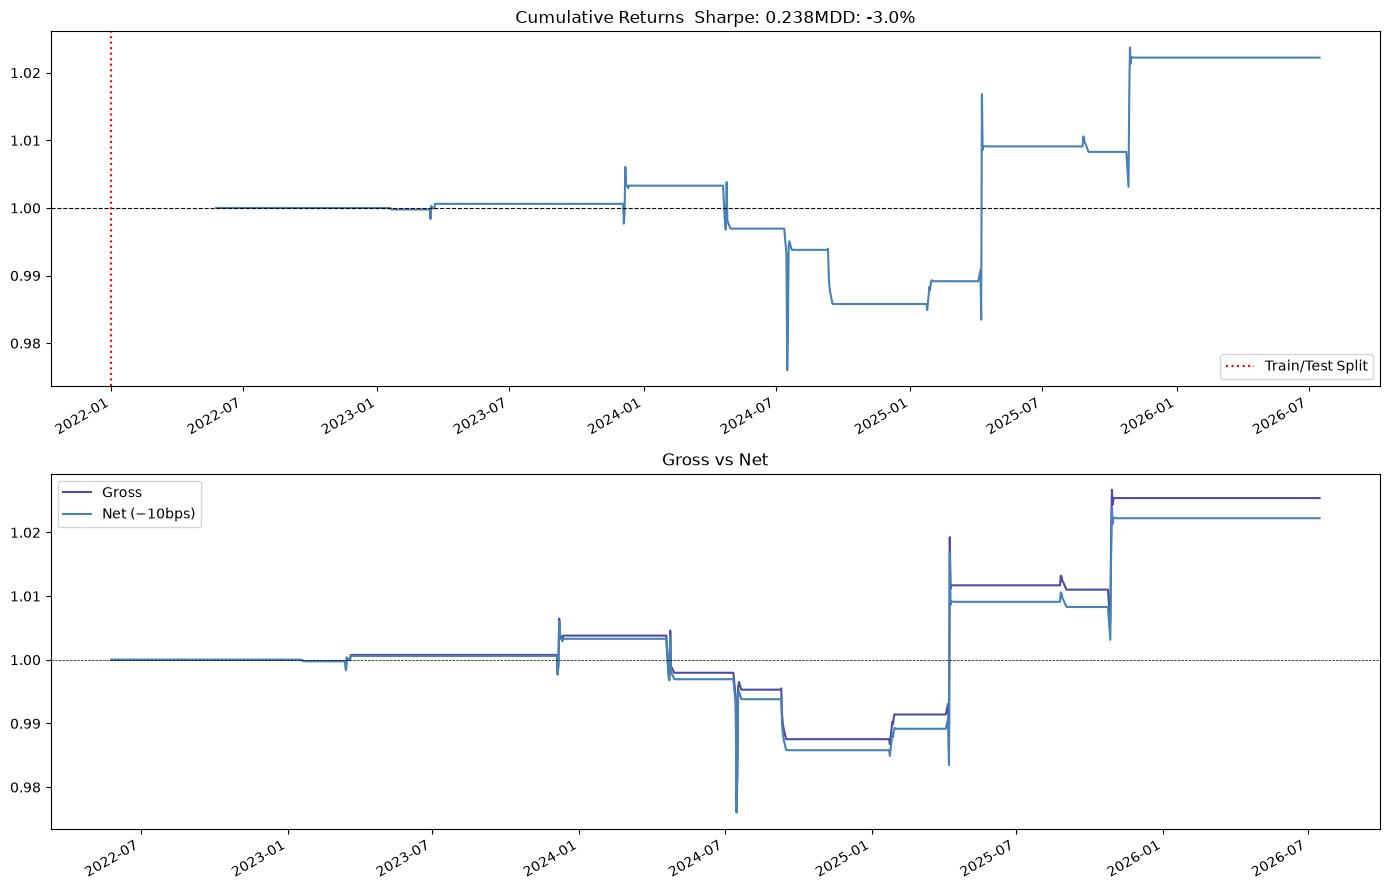

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

(1 + net_returns).cumprod().plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(pd.Timestamp(dt.test_start), color='red',
                linestyle=':', label='Train/Test Split')
axes[0].set_title(f"Cumulative Returns  Sharpe: {perf['sharpe_ratio']:.3f}"
                  f"MDD: {perf['max_drawdown']:.1%}")
axes[0].legend()

# Gross vs net
(1 + trades['gross_return']).cumprod().plot(ax=axes[1],
    label='Gross', alpha=0.7, color='navy')
(1 + trades['net_return']).cumprod().plot(ax=axes[1],
    label='Net (−10bps)', color='steelblue', linewidth=1.5)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=0.5)
axes[1].legend()
axes[1].set_title("Gross vs Net")
plt.tight_layout()
plt.show()

In [14]:
diag = bt.macro_regime_diagnostics(net_returns, macro_returns)
print("Sharpe by Macro Regime Quartile:")
print(diag.to_string())

Sharpe by Macro Regime Quartile:
          Q1     Q2     Q3     Q4
VIX    0.641 -2.010  0.193  0.578
Brent -0.500  0.399 -0.309  0.876


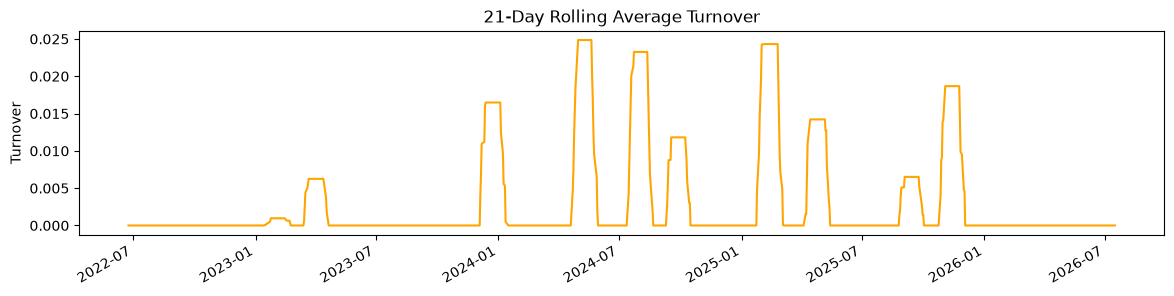

Avg daily turnover: 0.0030
Avg annual turnover: 0.75x


In [15]:
trades['turnover'].rolling(21).mean().plot(
    figsize=(14, 3), color='orange',
    title="21-Day Rolling Average Turnover"
)
plt.ylabel("Turnover")
plt.show()
print(f"Avg daily turnover: {trades['turnover'].mean():.4f}")
print(f"Avg annual turnover: {trades['turnover'].mean()*252:.2f}x")

In [16]:
net_returns.to_frame("net_return").to_csv(output_dir / "net_returns.csv")
perf.to_frame("strategy").to_csv(output_dir  / "performance.csv")
positions.to_csv(output_dir / "signals.csv")
trades.to_csv(output_dir / "trades.csv")
print("Saved.")

Saved.
